In [1]:
import numpy as np
from StatTools.generators.ndfnoise_generator import ndfnoise
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def gen_traj(frame_num: int, ants_num: int, frame_shape: tuple, margin:int = 10,
             hurst_move: float = 0.5, hurst_species: float = 0.5, 
             start_point = None):
    

    dx = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)
    dy = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)

    x = dx.round().cumsum(axis=0).astype(np.int32)
    y = dy.round().cumsum(axis=0).astype(np.int32)

    if start_point is None:
        start_x = np.random.randint(margin, frame_shape[1] - margin, (ants_num,))
        start_y = np.random.randint(margin, frame_shape[0] - margin, (ants_num,))
        start_point = np.stack([start_x, start_y], axis=1)

    trajectories = np.stack([x, y], axis=2)
    trajectories = trajectories + start_point

    return trajectories

def draw_traj(trajectories, frame_shape: tuple, ants_num: int):
    
    colors = sns.color_palette(palette='bright', n_colors=ants_num)
    colors = [tuple([int(c*255) for c in color]) for color in colors]

    bg = np.zeros(shape=(*frame_shape, 3), dtype=np.uint8)
    trajs = []
    for ant in range(trajectories.shape[1]):
        trajs.append(np.array([np.array(traj) for traj in trajectories[:, ant]]))
    for ant, color in  zip(trajs, colors):

        cv2.polylines(bg, [ant], isClosed=False, color=color, thickness=2)

    # Display with matplotlib
    plt.imshow(cv2.cvtColor(bg, cv2.COLOR_BGR2RGB))
    plt.show()

def draw_ants_with_direction(trajectories, frame_num: int, ants_num: int, frame_shape: tuple, margin:int = 10,
             hurst_move: float = 0.5, hurst_species: float = 0.5, 
             start_point = None, ant_length = 5, ant_width=2):
    
    
    for frame_idx in range(frame_num):
        frame = np.zeros((*frame_shape, 3), dtype=np.uint8)
        
        for ant_idx in range(ants_num):
            
            x, y = trajectories[frame_idx, ant_idx]
            
            
            if frame_idx < trajectories.shape[0] - 1:
                dx = trajectories[frame_idx + 1, ant_idx, 0] - x
                dy = trajectories[frame_idx + 1, ant_idx, 1] - y
                angle = np.arctan2(dy, dx) * 180 / np.pi
            else:
                angle = 0
            
            
            center = (int(x), int(y))
            axes = (ant_length, ant_width)
            cv2.ellipse(frame, center, axes, angle, 0, 360, 
                       (0, 255, 0), -1)
        frame=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        cv2.imshow('frame', frame)
        if cv2.waitKey(1) & 0xFF == 27:
            break


c:\Users\akhiyarov.si\Documents\asp\NMOT\StatTools\generators\ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in power
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))
c:\Users\akhiyarov.si\Documents\asp\NMOT\StatTools\generators\ndfnoise_generator.py:55: RuntimeWarning: invalid value encountered in multiply
  S *= np.abs(f_last.reshape((1,) * (dim - 1) + (-1,))) ** (-(hurst[-1] - 0.5))


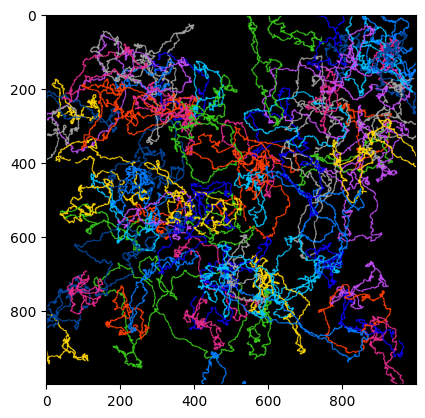

In [2]:

np.random.seed(42)

config = {
'frame_num' : 1000,
'frame_shape' : (1000, 1000),
'margin': 50,
'hurst_move': 0.9,
'hurst_species': 0.1,
'ants_num' : 100,
'start_point' : None
}
trajectories = gen_traj(**config)
draw_traj(trajectories, config['frame_shape'],  config['ants_num'])

draw_ants_with_direction(trajectories, **config)